# Credit Risk Analysis
### Predicting Credit Risk with Random Forest, Decision Tree and XGBoost Classifiers.

## Business Understanding


## Data Understanting


|Feature|Data Type|Purpose|Values|
|-------|---------|-------|------|
|Age|int| Person's age| Numeric|
|Sex|str| Person's sex| Male/Female|
|Job|int| A person's job| 0 - Unskilled and non-resident, 1 - Skilled and resident, 2 - Skilled, 3 - Highly skilled|
|Housing|str| Represents the type of housing a person has|rent, own or free|
|Savings accounts|str| The amount of money a person has in their savings accounts| little, moderate, quite rich, rich|
|Checking account|int| The amount of money a person has in their checking acount| Deutsch Mark|
|Credit amount|int| Represents the credit line of a person| Deutsch Mark|
|Duration|int| Represents the amount of months left in the credit line| Numeric|
|Purpose| str|Represents the purpose of the credit line| car, furniture/equipment, radio/TV, domestic appliances, repairs, education, business, vacation/others.|
|Risk|str|Represents the credit risk| Good = Low, Bad = High|

## 1. Setup and Imports


### 1.1. Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

### 1.2 Plot styling

In [2]:
plt.rcParams['font.size'] = 14          # Default text size
plt.rcParams['axes.labelsize'] = 16    # Axis labels
plt.rcParams['axes.titlesize'] = 18    # Title size
plt.rcParams['xtick.labelsize'] = 14   # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 14   # Y-axis tick labels
plt.style.use('fivethirtyeight') # Plots styling
plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'blue',
    'ytick.color': 'blue'
})   

## 2. Dataset Loading and Initial Data Exploration

### 2.1. Load Dataset

In [3]:
df = pd.read_csv('german_credit_data.csv', index_col=0)

### 2.2. Analyze Data's State

In [4]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [5]:
df.tail()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad
999,27,male,2,own,moderate,moderate,4576,45,car,good


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 85.9+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,"1,000.00",35.55,11.38,19.00,27.00,33.00,42.00,75.00
Job,"1,000.00",1.90,0.65,0.00,2.00,2.00,2.00,3.00
Credit amount,"1,000.00","3,271.26","2,822.74",250.00,"1,365.50","2,319.50","3,972.25","18,424.00"
Duration,"1,000.00",20.90,12.06,4.00,12.00,18.00,24.00,72.00


In [8]:
df.describe(include='object').T

,count,unique,top,freq
Sex,1000,2,male,690
Housing,1000,3,own,713
Saving accounts,817,4,little,603
Checking account,606,3,little,274
Purpose,1000,8,car,337
Risk,1000,2,good,700


In [9]:
# Number of unique values
df.nunique()

Age                  53
Sex                   2
Job                   4
Housing               3
Saving accounts       4
Checking account      3
Credit amount       921
Duration             33
Purpose               8
Risk                  2
dtype: int64

In [10]:
# Percentage of null values in dataset
df.isnull().sum()/len(df)*100

Age                 0.00
Sex                 0.00
Job                 0.00
Housing             0.00
Saving accounts    18.30
Checking account   39.40
Credit amount       0.00
Duration            0.00
Purpose             0.00
Risk                0.00
dtype: float64

- `Savings accounts` and `Checking account` have missing values, maybe some people dont have savings accounts or checking accounts, I'll have to address that later. 

In [11]:
df.isnull().sum().sum()

np.int64(577)

- 57,7% of the `Savings account` and `Checking account` values are `NaN`.

- I'll have to create a `none` class (no account) to preserve the features.

In [12]:
# Target Distribuition
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

- Class imbalance, need to apply balancing techniques.

In [13]:
df.shape

(1000, 10)

In [14]:
df['Saving accounts'] = df['Saving accounts'].fillna('none')
df['Checking account'] = df['Checking account'].fillna('none')

## 3. Exploratory Data Analysis
- Target Distribution
- Feature x Target
- Feature Correlations

### 3.1. Target distribution

In [15]:
# Target distribution
df['Risk'].value_counts(normalize=True)

Risk
good   0.70
bad    0.30
Name: proportion, dtype: float64

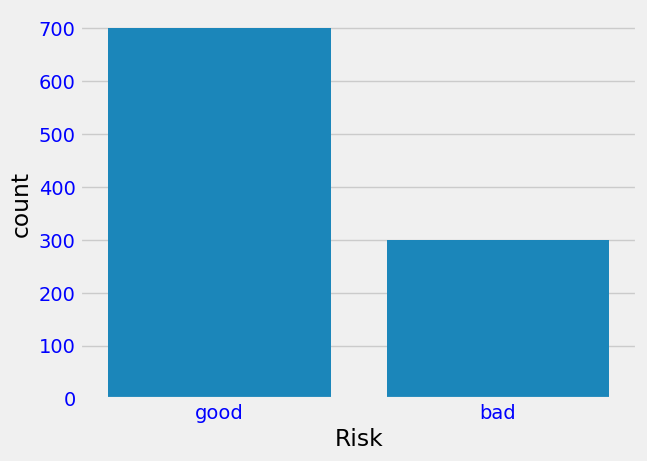

In [16]:
sns.countplot(x='Risk', data=df)
plt.show()

### 3.2. Numeric features distributions

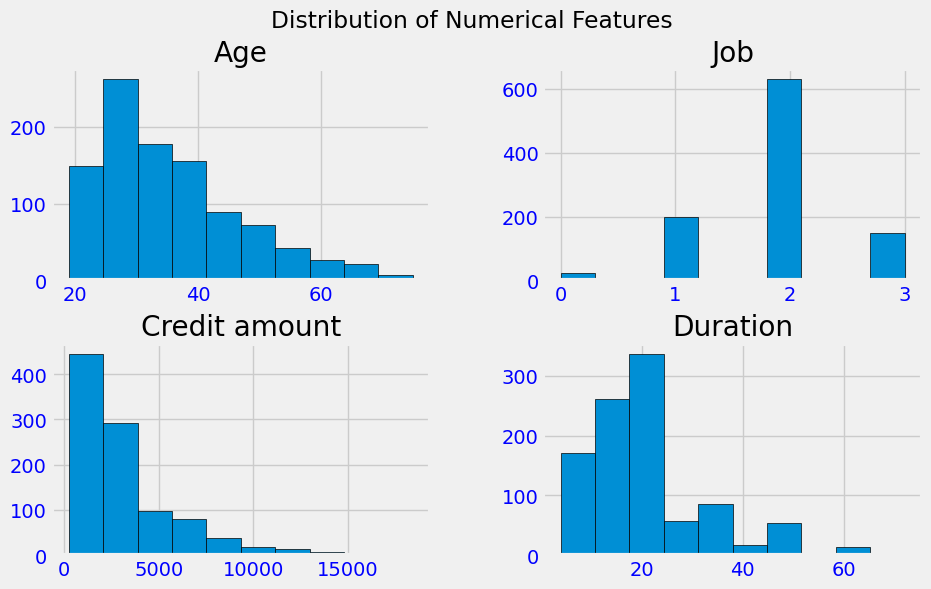

In [17]:
df.hist(
    bins=10,
    figsize=(10, 6),
    edgecolor="black"
)
plt.suptitle("Distribution of Numerical Features")
plt.show()

- **Outliers**: Present in `Age`, `Credit amount` and `Duration`, however, all outliers are legitimate (old people exist, so do high amounts of money and time.).

- **Job**: Most people are `2 - Skilled`

- **Means**: Majority of `Credit amount` is <= 5000, `Duration` <= 20 and `Age` between 20 - 40.

In [18]:
# Verifying stats to find outlier values
df[['Age', 'Credit amount', 'Duration']].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,"1,000.00",35.55,11.38,19.00,27.00,33.00,42.00,75.00
Credit amount,"1,000.00","3,271.26","2,822.74",250.00,"1,365.50","2,319.50","3,972.25","18,424.00"
Duration,"1,000.00",20.90,12.06,4.00,12.00,18.00,24.00,72.00


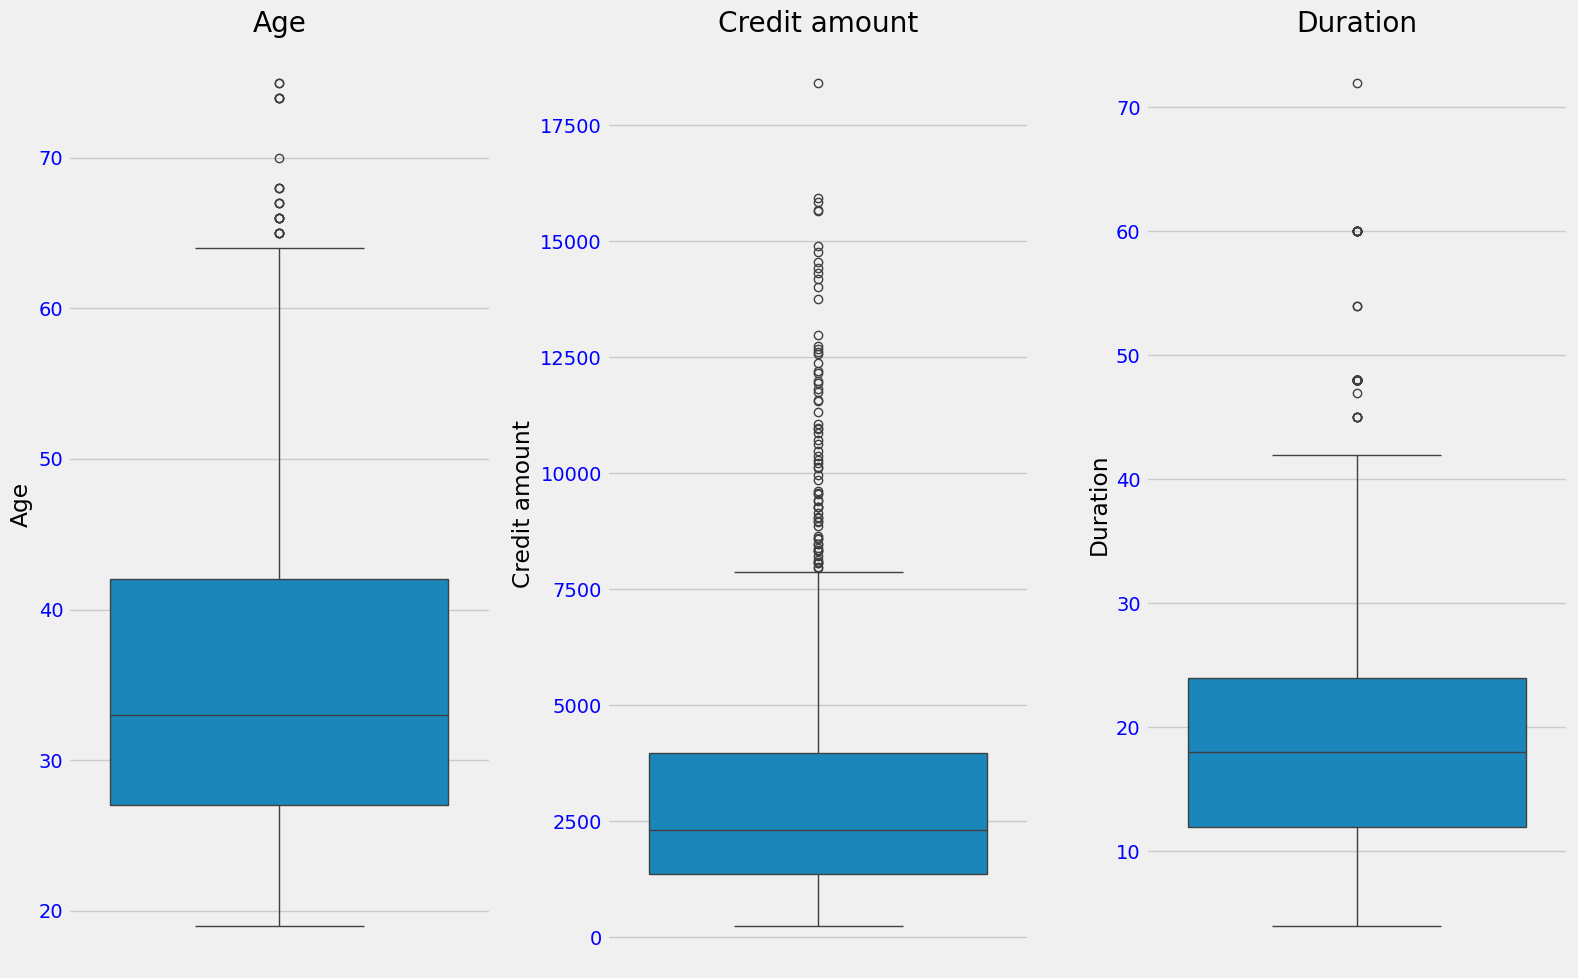

In [19]:
# Outliers in age, credit amount and duration
plt.figure(figsize=(16, 10))
for i, col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

- **Age**: Individuals up to 75 years old are valid credit applicants.

- **Credit amount**: Values up to 18,000 DM are reasonable depending 
  on purpose (e.g. business, car, home improvement).
  
- **Duration**: 72-month terms are standard for housing and major 
  purchases.

### 3.3. Categorical features distributions

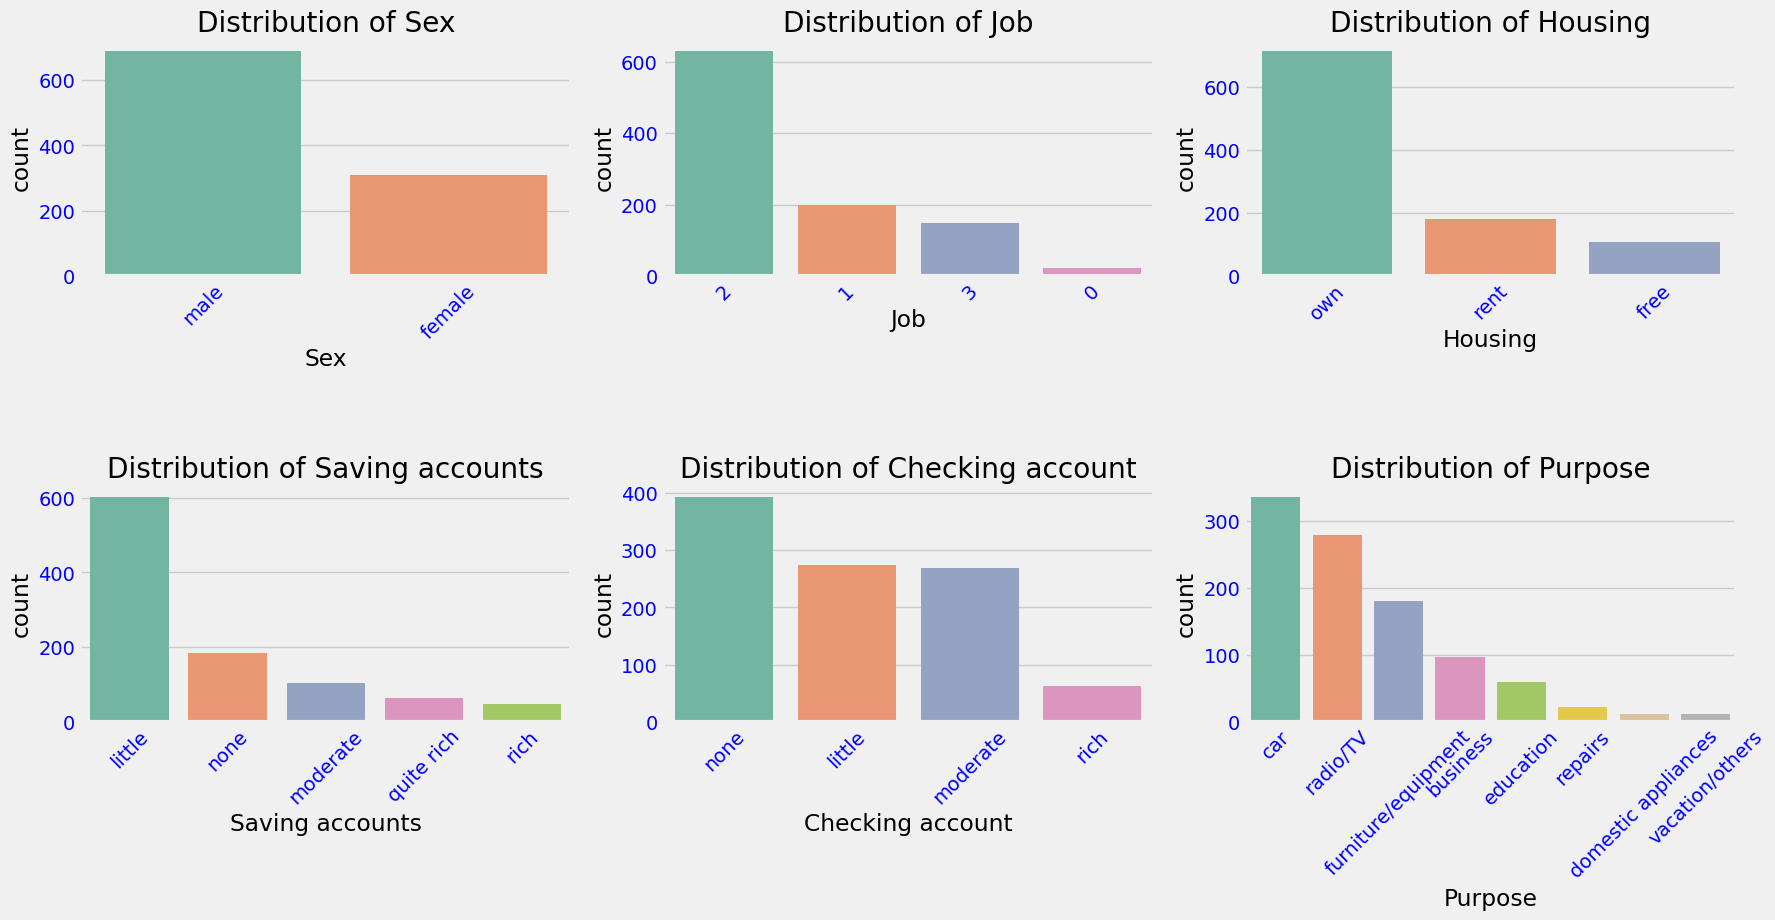

In [20]:
categorical_cols = [
    "Sex",
    "Job",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Purpose"
]

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- **Sex**: Majoriry of males.
- **Job**: Majority of 2 - Skilled individuals.
- **Housing**: Majority of home owners.
- **Saving accounts**: Most people have little or no savings.
- **Checking account**: Most people have no checking account or little account balances.
- **Purpose**: Majority of people have asset-based credit lines with collaterals.

### 3.4.  Target x Features

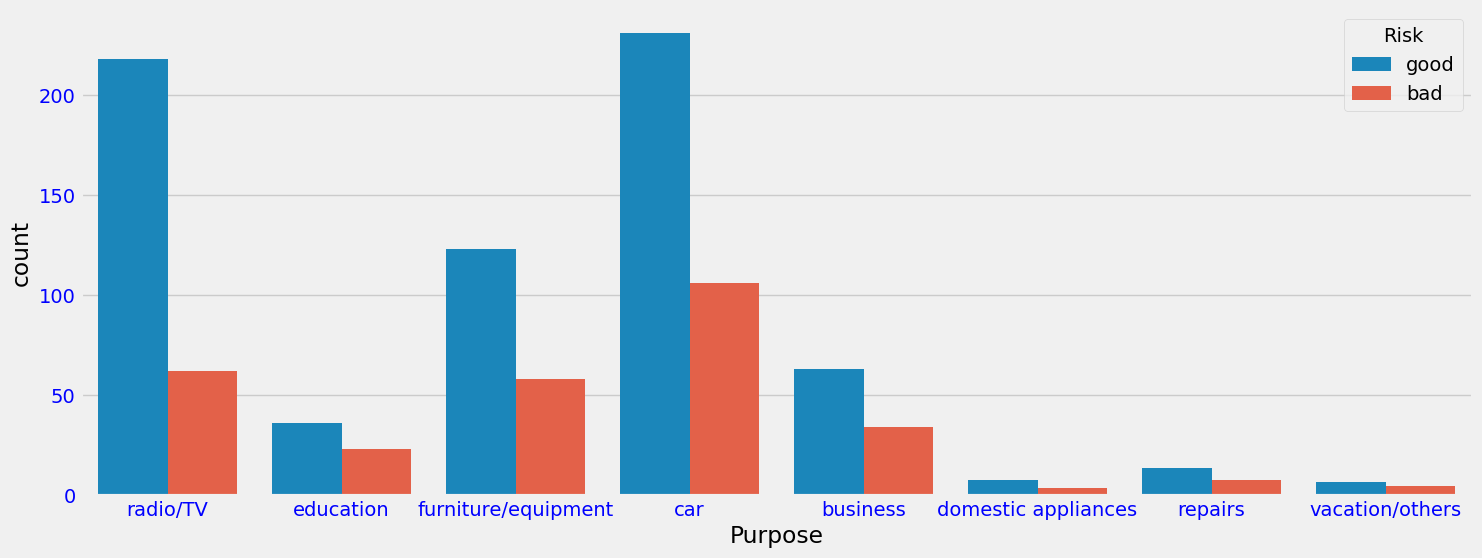

In [21]:
# Purpose x Risk
plt.figure(figsize=(16, 6))
sns.countplot(x='Purpose', hue='Risk', data=df)
plt.show()

In [22]:
# Real proof
df.groupby('Purpose')['Risk'].value_counts(normalize=True).unstack().style.background_gradient(
    cmap='RdYlGn',
    axis=1
).format('{:.2%}')

Risk,bad,good
Purpose,,
business,35.05%,64.95%
car,31.45%,68.55%
domestic appliances,33.33%,66.67%
education,38.98%,61.02%
furniture/equipment,32.04%,67.96%
radio/TV,22.14%,77.86%
repairs,36.36%,63.64%
vacation/others,41.67%,58.33%


- **Risk**: Is higher in `education`, `business` and `vacation/others`. **Reasoning**:

    - `education`: Students typically lack immediate income to pay debt, return on education is long-term and uncertain.

    - `business`: Business carry high failure risks and often lack stable collateral, repayment is unpredictable.

    - `vacation/others`: Non-essential, consumption-based credit with no collateral assets contrast with asset-backed purposes, like `car`, or `furniture/equipment`, which serve as implicit collaterals.

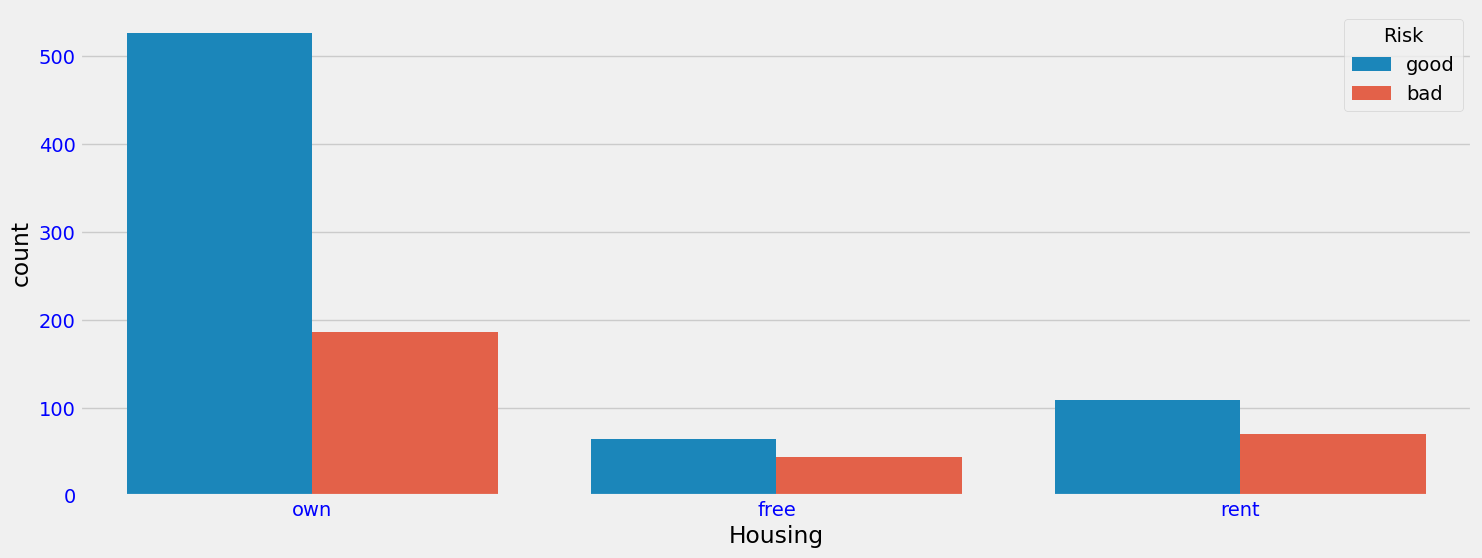

In [23]:
# Housing x Risk
plt.figure(figsize=(16, 6))
sns.countplot(x='Housing', hue='Risk', data=df)
plt.show()

In [24]:
# Real proof
df.groupby('Housing')['Risk'].value_counts(normalize=True).unstack().style.background_gradient(
    cmap='RdYlGn',
    axis=1
).format('{:.2%}')

Risk,bad,good
Housing,,
free,40.74%,59.26%
own,26.09%,73.91%
rent,39.11%,60.89%


- **Risk**: Higher bad risk rate in `rent` (39.11%) and `free` (40.74%) 
  housing categories compared to `own` (26.09%). **Reasoning**: 
  
  - Renters and individuals in free housing lack real estate assets, which typically serve as collateral and signal financial stability. Homeowners present nearly half the default rate of non-owners.

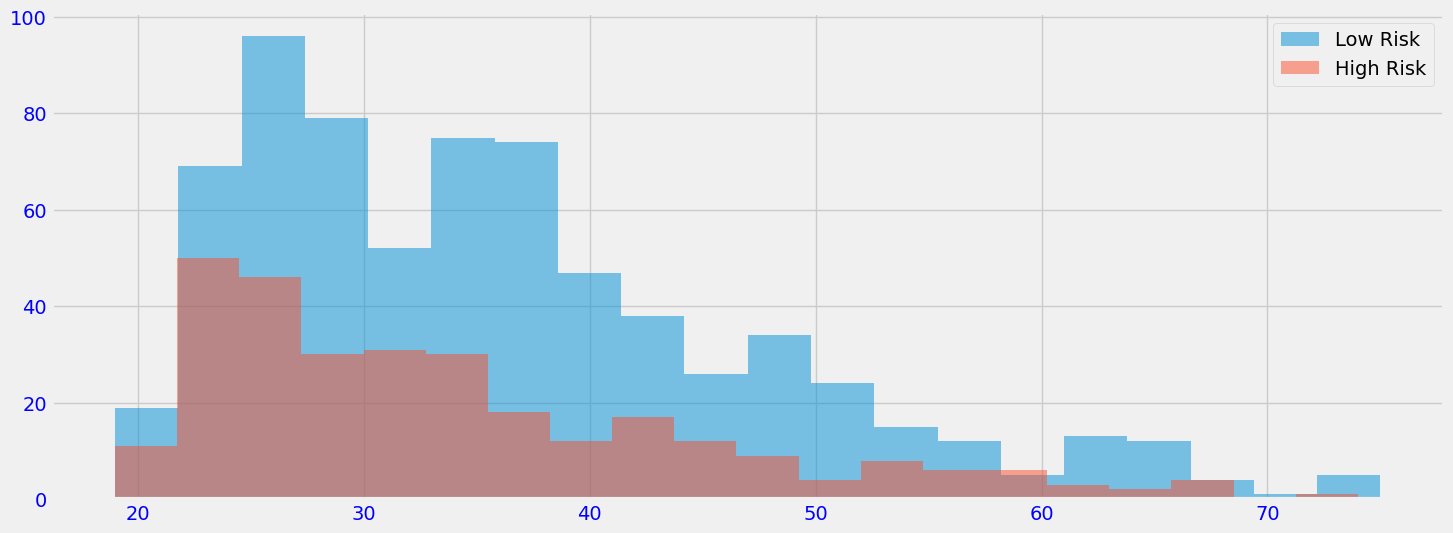

In [25]:
# Age x Risk
plt.figure(figsize=(16, 6))
df[df['Risk'] == 'good']['Age'].hist(
    bins=20,
    alpha=0.5,
    label='Low Risk'
)
df[df['Risk'] == 'bad']['Age'].hist(
    bins=20,
    alpha=0.5,
    label='High Risk'
)
plt.legend()
plt.show()

In [26]:
# Real proof
df['Age group'] = pd.cut(df['Age'], bins=range(10, 90, 10))
df.groupby('Age group')['Risk'].value_counts(normalize=True).unstack().style.background_gradient(
    cmap='RdYlGn',
    axis=1
).format('{:.2%}')

Risk,bad,good
Age group,,
"(10, 20]",37.50%,62.50%
"(20, 30]",35.95%,64.05%
"(30, 40]",25.40%,74.60%
"(40, 50]",25.47%,74.53%
"(50, 60]",30.88%,69.12%
"(60, 70]",23.08%,76.92%
"(70, 80]",16.67%,83.33%


- **Risk vs Age**: Both `good` (low) and `bad` (high) risk profiles are concentrated in the 20–30 age range, reflecting the dataset's overall age distribution. However, good risk shows a secondary concentration between 30–40, suggesting that financial stability increases with age.

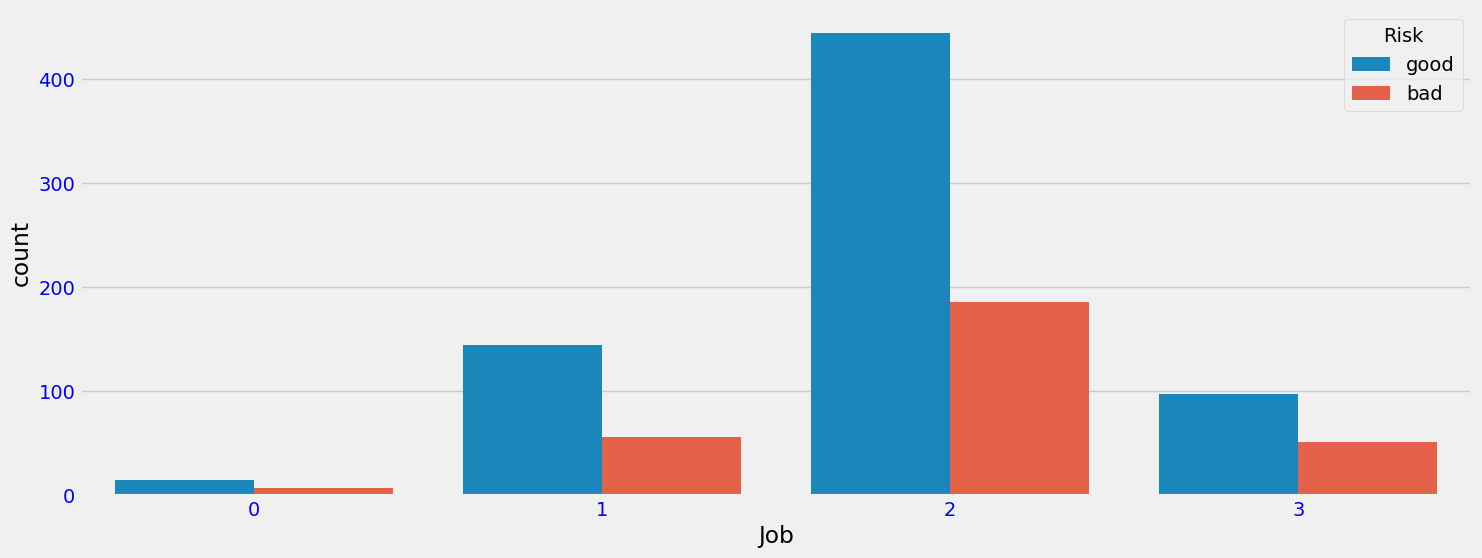

In [27]:
# Job x Risk
plt.figure(figsize=(16, 6))
sns.countplot(x='Job', hue='Risk', data=df)
plt.show()

In [28]:
# Real proof
df.groupby('Job')['Risk'].value_counts(normalize=True).unstack().style.background_gradient(
    cmap='RdYlGn',
    axis=1
).format('{:.2%}')

Risk,bad,good
Job,,
0,31.82%,68.18%
1,28.00%,72.00%
2,29.52%,70.48%
3,34.46%,65.54%


- **Risk vs Job**: Higher risk can be observed from 0 - **Unskilled and non-resident**, which makes sense, and **3 - Highly skilled**. To be sure of how to analyse this, I should compare Job x Age and Job x Purpose.

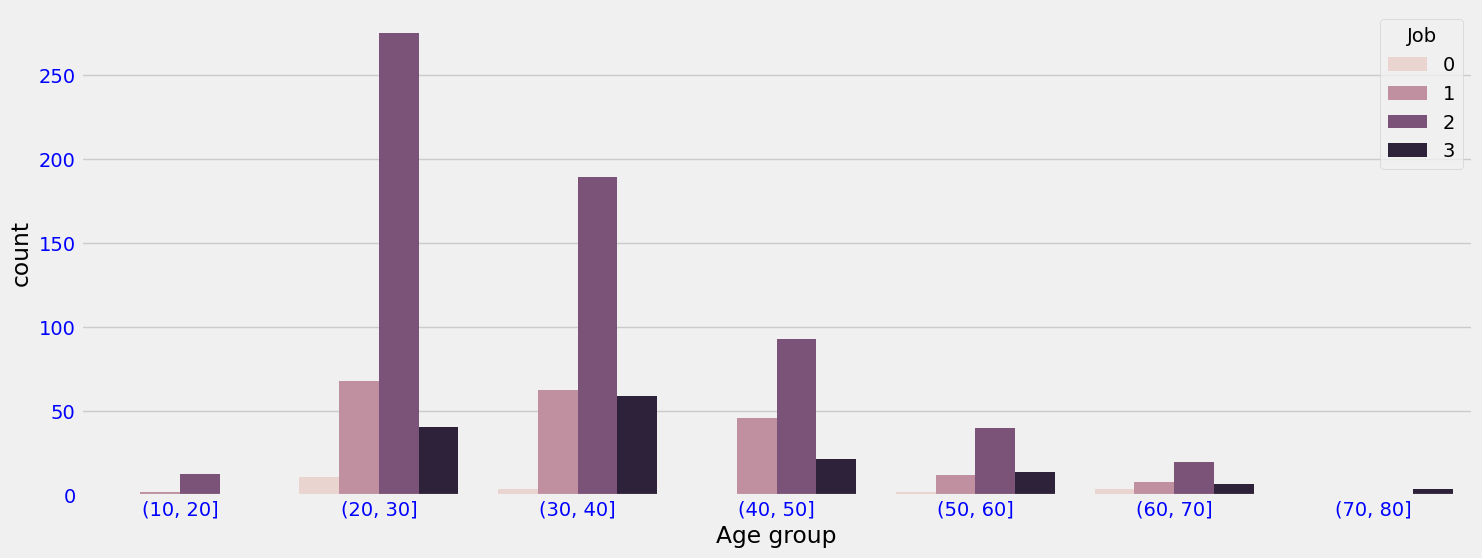

In [29]:
# Job x Age group
plt.figure(figsize=(16, 6))
sns.countplot(x='Age group', hue='Job', data=df)
plt.show()

In [30]:
# Real proof
df.groupby('Job')['Age group'].value_counts(normalize=True).unstack().style.background_gradient(
    cmap='RdYlGn',
    axis=1
).format('{:.2%}')

Age group,"(10, 20]","(20, 30]","(30, 40]","(40, 50]","(50, 60]","(60, 70]","(70, 80]"
Job,,,,,,,
0,0.00%,50.00%,18.18%,0.00%,9.09%,18.18%,4.55%
1,1.00%,34.00%,31.50%,23.00%,6.00%,4.00%,0.50%
2,2.06%,43.65%,30.00%,14.76%,6.35%,3.17%,0.00%
3,0.68%,27.70%,39.86%,14.86%,9.46%,4.73%,2.70%


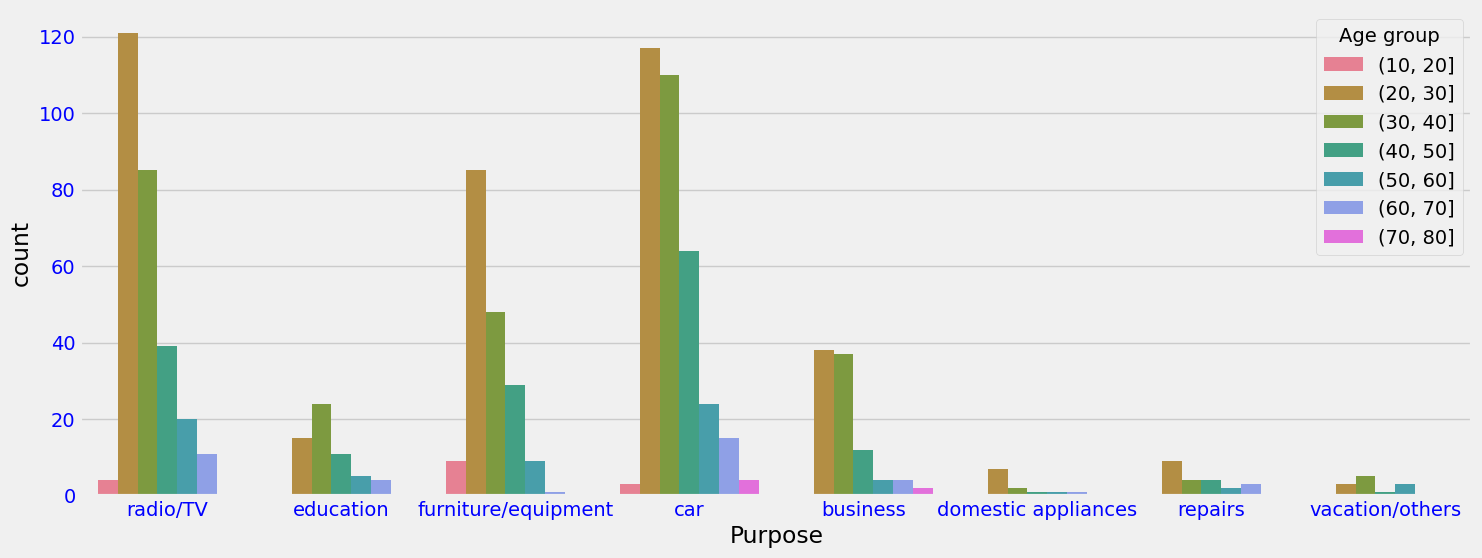

In [31]:
# Job x Risk
plt.figure(figsize=(16, 6))
sns.countplot(x='Purpose', hue='Age group', data=df)
plt.show()

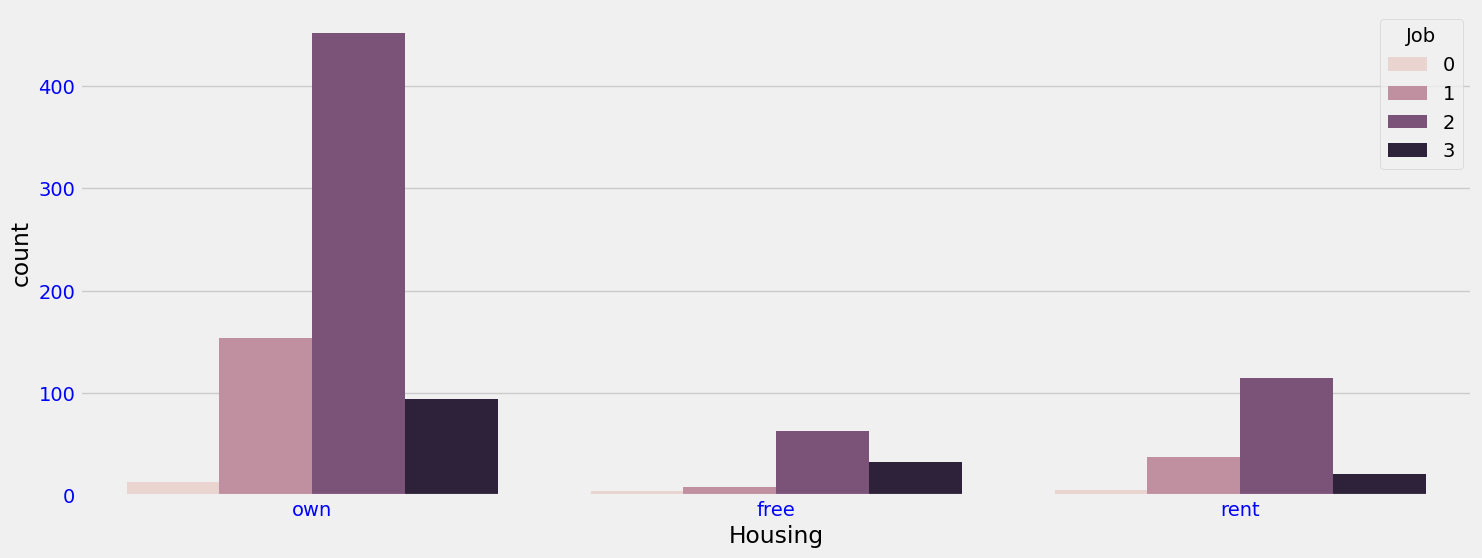

In [32]:
# Housing x Job
plt.figure(figsize=(16, 6))
sns.countplot(x='Housing', hue='Job', data=df)
plt.show()

- **Risk vs Job**: Inconclusive, perhaps the higher risk that comes from 3 - **Highly skilled** can be explained **in this dataset** by the age group with higher risks, which is (20, 40].

In [33]:
# Job x Credit amount
df.groupby('Job')['Credit amount'].mean()

Job
0   2,745.14
1   2,358.52
2   3,070.97
3   5,435.49
Name: Credit amount, dtype: float64

- Higher `Credit amount` for highly educated individuals, probably because of higher income and better housing.

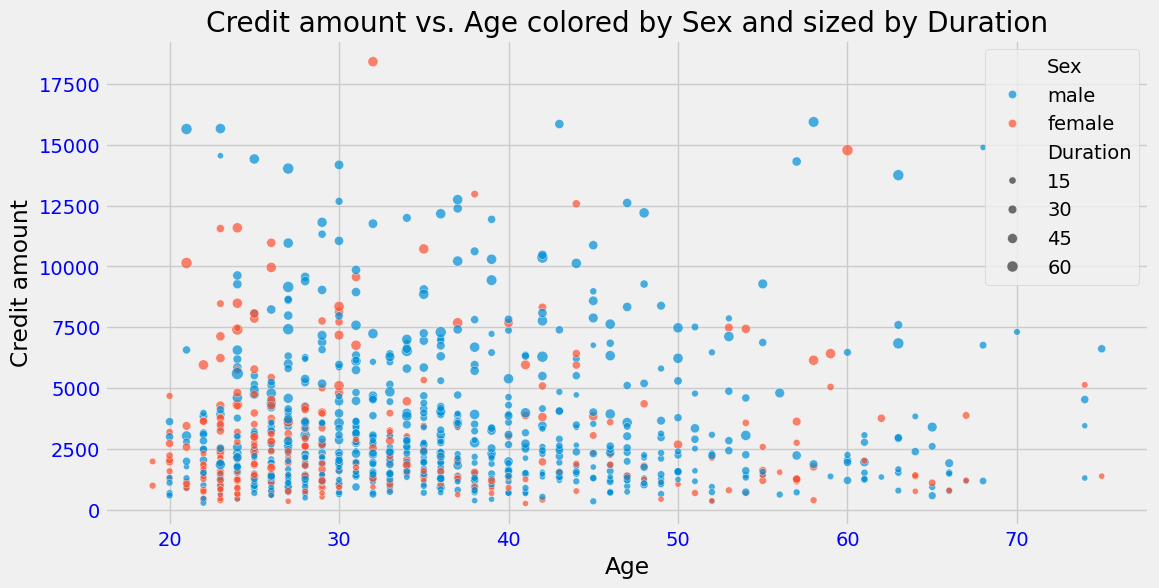

In [34]:
# Credit amount x Age x Sex x Duration
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df,
                x="Age",
                y="Credit amount",
                hue="Sex",
                size="Duration",
                alpha=0.7)

plt.title("Credit amount vs. Age colored by Sex and sized by Duration")
plt.show()


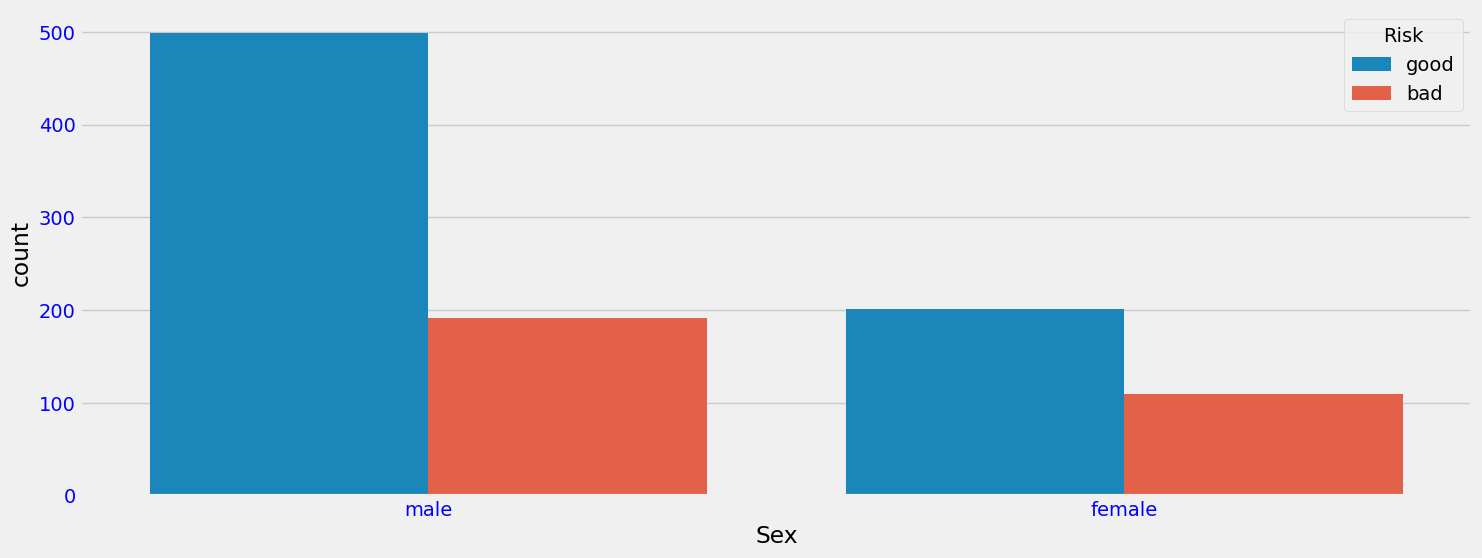

In [35]:
# Sex x Risk
plt.figure(figsize=(16, 6))
sns.countplot(x='Sex', hue='Risk', data=df)
plt.show()

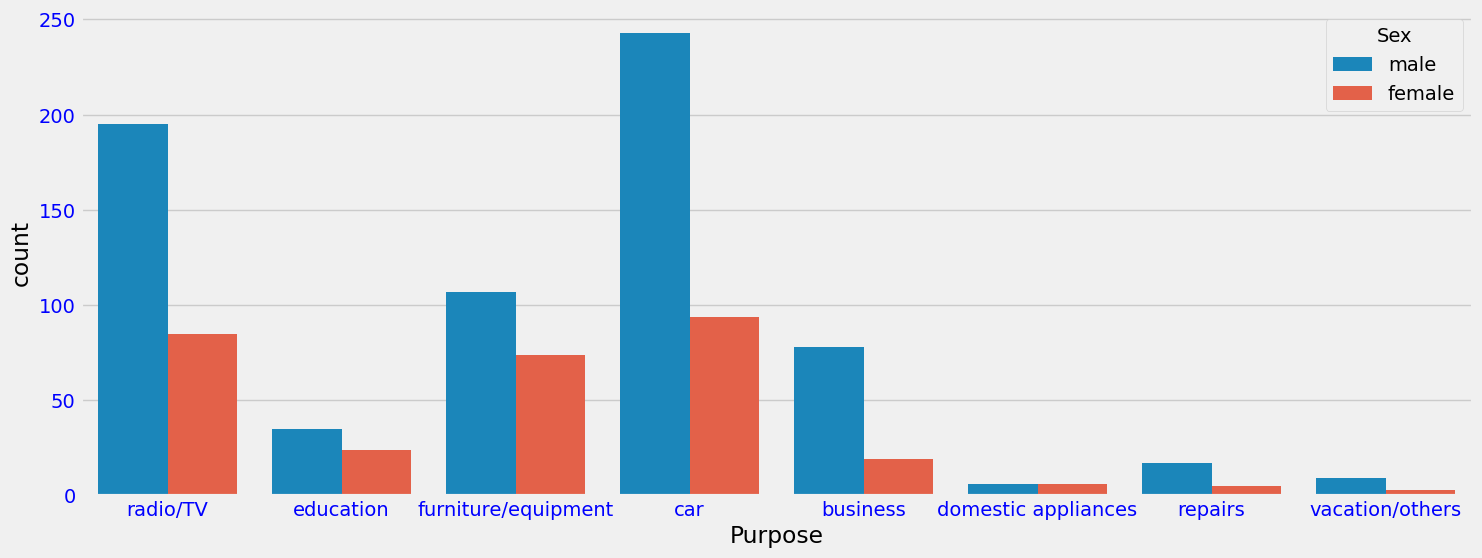

In [36]:
# Sex x Purpose
plt.figure(figsize=(16, 6))
sns.countplot(x='Purpose', hue='Sex', data=df)
plt.show()

In [37]:
# Real proof
df.groupby('Sex')['Risk'].value_counts(normalize=True).unstack().style.background_gradient(
    cmap='RdYlGn',
    axis=1
).format('{:.2%}')

Risk,bad,good
Sex,,
female,35.16%,64.84%
male,27.68%,72.32%


In [38]:
# Real proof
df.groupby('Sex')['Purpose'].value_counts().unstack().T.style.background_gradient(
    cmap='RdYlGn',
    axis=1
)

Sex,female,male
Purpose,,
business,19,78
car,94,243
domestic appliances,6,6
education,24,35
furniture/equipment,74,107
radio/TV,85,195
repairs,5,17
vacation/others,3,9


- Higher concentration of `female` in `furniture/equipment` and `education`.

### Conclusion

- Higher risk in `free` and `rent` housing.

- Higher risk for younger age groups (20 - 30).

- Higher risk for `business`, `education` and `vacation/other` purposes.

- Higher risk for females than males.

- Legitimate outliers.


## 4. Feature Engineering


### 4.1. Feature target split

In [39]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk', 'Age group'],
      dtype='object')

In [40]:
df['Credit per month'] = df['Credit amount']/df['Duration']

In [41]:
features = ['Age',
            'Sex',
            'Job',
            'Housing',
            'Saving accounts',
            'Checking account',
            'Credit amount',
            'Credit per month',
            'Duration']
joblib.dump(features, 'feature_names.pkl')

['feature_names.pkl']

### 4.2. Column mapping

In [42]:
target = 'Risk'
target_mapping = {"good": 1, "bad": 0}
joblib.dump(target_mapping, 'target_mapping.pkl')

['target_mapping.pkl']

In [43]:
df_model = df[features + [target]].copy()

In [44]:
df_model = df_model.rename(columns={
    'Credit amount': 'credit_amount',
    'Saving accounts': 'saving_accounts',
    'Checking account': 'checking_account',
    'Age': 'age',
    'Housing': 'housing',
    'Credit per month': 'credit_per_month',
    'Duration': 'duration',
    'Sex':'sex',
    'Job':'job',
    'Risk':'risk'
})

In [45]:
df_model.head()

,age,sex,job,housing,saving_accounts,checking_account,credit_amount,credit_per_month,duration,risk
0,67,male,2,own,none,little,1169,194.83,6,good
1,22,female,2,own,little,moderate,5951,123.98,48,bad
2,49,male,1,own,little,none,2096,174.67,12,good
3,45,male,2,free,little,little,7882,187.67,42,good
4,53,male,2,free,little,little,4870,202.92,24,bad


### 4.3. Label/Feature encoding

In [46]:
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [47]:
cat_cols = df_model.select_dtypes(include='object').columns.drop('risk')

In [48]:
label_encoder_dict = {}

In [49]:
cat_cols

Index(['sex', 'housing', 'saving_accounts', 'checking_account'], dtype='object')

In [50]:
# Label encoding - features
for col in cat_cols:
    feat_label_encoder = LabelEncoder()
    df_model[col] = feat_label_encoder.fit_transform(df_model[col])
    label_encoder_dict[col] = feat_label_encoder
    joblib.dump(feat_label_encoder, f"{col}_encoder.pkl")

In [51]:
# Label encoding - target
target_label_encoder = LabelEncoder()

In [52]:
target = "risk"

In [53]:
df_model[target] = target_label_encoder.fit_transform(df_model[target])


In [54]:
df['Risk'].head()

0    good
1     bad
2    good
3    good
4     bad
Name: Risk, dtype: object

In [55]:
df_model['risk'].head()

0    1
1    0
2    1
3    1
4    0
Name: risk, dtype: int64

- Good - 1; Bad - 0.

In [ ]:
df_model[target].value_counts()

risk
1    700
0    300
Name: count, dtype: int64

In [57]:
joblib.dump(target_label_encoder, "target_encoder.pkl")

['target_encoder.pkl']

In [58]:
df_model.head()

,age,sex,job,housing,saving_accounts,checking_account,credit_amount,credit_per_month,duration,risk
0,67,1,2,1,2,0,1169,194.83,6,1
1,22,0,2,1,0,1,5951,123.98,48,0
2,49,1,1,1,0,2,2096,174.67,12,1
3,45,1,2,0,0,0,7882,187.67,42,1
4,53,1,2,0,0,0,4870,202.92,24,0


## 5. ML Pipeline

### 5.1. Train test split

In [59]:
# Preprocessing and Metrics
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer

# Models
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


In [60]:
X = df_model.drop(target, axis=1)

In [61]:
X.head()

,age,sex,job,housing,saving_accounts,checking_account,credit_amount,credit_per_month,duration
0,67,1,2,1,2,0,1169,194.83,6
1,22,0,2,1,0,1,5951,123.98,48
2,49,1,1,1,0,2,2096,174.67,12
3,45,1,2,0,0,0,7882,187.67,42
4,53,1,2,0,0,0,4870,202.92,24


In [62]:
y = df_model[target]

In [63]:
y.head()

0    1
1    0
2    1
3    1
4    0
Name: risk, dtype: int64

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.20,
    random_state = 42,
    stratify=y
)

In [65]:
from sklearn.metrics import f1_score
from pprint import pprint
def train_model_f1(
    model,
    param_grid,
    X_train,
    y_train,
    X_test,
    y_test):
    """Hyper-function for model training"""
    try:
        grid = GridSearchCV(
            model, param_grid, cv=5, scoring="f1", n_jobs=-1
        )
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)
        f1 = f1_score(y_test, y_pred)
        return best_model, f1, grid.best_params_
    except Exception as e:
        pprint(f"Error training model: {e}")

### 5.2. Cross Validation

#### 5.2.1. Decision Tree Classifier

In [66]:
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight = "balanced"
)
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [67]:
best_dt, f1_dt, params_dt = train_model_f1(
    dt, dt_param_grid, X_train, y_train, X_test, y_test
)

In [68]:
print(f"Decision Tree Accuracy: {f1_dt}")
print(f"Best Parameters: {params_dt}")
print(f"Best DecisionTree: {best_dt}")

Decision Tree Accuracy: 0.7713310580204779
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best DecisionTree: DecisionTreeClassifier(class_weight='balanced', random_state=42)


#### 5.2.2. Extra Tree Classifier

In [69]:
et = ExtraTreeClassifier(
    random_state=42,
    class_weight = "balanced"
)
et_param_grid = {
    "max_depth": [5, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [70]:
best_et, f1_et, params_et = train_model_f1(
    et, et_param_grid, X_train, y_train, X_test, y_test
)

In [72]:
print(f"Extra Decision Tree F1: {f1_et}")
print(f"Best Parameters: {params_et}")
print(f"Best ExtraDecisionTree: {best_et}")

Extra Decision Tree F1: 0.7567567567567568
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best ExtraDecisionTree: ExtraTreeClassifier(class_weight='balanced', max_depth=10, random_state=42)


#### 5.2.3. Random Forest Classifier

In [73]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight = "balanced",
    n_jobs=-1
)
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [74]:
best_rf, f1_rf, params_rf = train_model_f1(
    rf, rf_param_grid, X_train, y_train, X_test, y_test
)

In [75]:
print(f"Random Forest F1: {f1_rf}")
print(f"Best Parameters: {params_rf}")
print(f"Best RandomForest: {best_rf}")

Random Forest F1: 0.8367346938775511
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best RandomForest: RandomForestClassifier(class_weight='balanced', max_depth=10, n_jobs=-1,
                       random_state=42)


#### 5.2.4. Extreme Gradient Boosting Classifier

In [76]:
xgb = XGBClassifier(
    random_state=42,
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),
    use_label_encoder=False,
    eval_metric="logloss",
    n_jobs=-1
)
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7, 10, None],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1],
    "colsample_bytree": [0.7, 1]
}

In [77]:
best_xgb, f1_xgb, params_xgb = train_model_f1(
    xgb, xgb_param_grid, X_train, y_train, X_test, y_test
)

In [78]:
print(f"XGBoost Logloss: {f1_xgb}")
print(f"Best Parameters: {params_xgb}")
print(f"Best XGBoost: {best_xgb}")

XGBoost Logloss: 0.7832167832167832
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': None, 'n_estimators': 200, 'subsample': 0.7}
Best XGBoost: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)


### Conclusion - Classifier Scores
1. **RandomForest**: `0.836`
2. **XGBoost**: `0.783`
3. **Decision** Tree: `0.771`
4. **Extra Tree**: `0.685`


### 5.3. CV and Pipeline with SMOTE

#### 5.3.1. Random Forest Classifier with SMOTE

In [79]:
rf_smote_pipeline = ImbPipeline([    
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight = "balanced",
        n_jobs=-1
    ))
])

rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [3, 5, 7, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    rf_smote_pipeline,
    rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)
y_pred = grid.predict(X_test)
rf_f1_smote = f1_score(y_test, y_pred)

In [80]:
pprint(f"RF with SMOTE F1 {rf_f1_smote}")
pprint(f"Best params RF SMOTE {grid.best_params_}")

'RF with SMOTE F1 0.8421052631578947'
("Best params RF SMOTE {'classifier__max_depth': None, "
 "'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, "
 "'classifier__n_estimators': 100}")


#### 5.3.2. Extreme Gradient Boosting Classifier with SMOTE

In [81]:
xgb_smote_pipeline = ImbPipeline([    
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        random_state=42,
        class_weight = "balanced",
        n_jobs=-1
    ))
])

xgb_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [3, 5, 7, 10, None],
    "classifier__learning_rate": [0.01, 0.1, 0.2],
    "classifier__subsample": [0.7, 1],
    "classifier__colsample_bytree": [0.7, 1]
}

grid = GridSearchCV(
    xgb_smote_pipeline,
    xgb_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)
y_pred = grid.predict(X_test)
xgb_f1_smote = f1_score(y_test, y_pred)



In [82]:
pprint(f"XGB with SMOTE F1 {xgb_f1_smote}")
pprint(f"Best params XGB SMOTE {grid.best_params_}")

'XGB with SMOTE F1 0.8214285714285714'
("Best params XGB SMOTE {'classifier__colsample_bytree': 0.7, "
 "'classifier__learning_rate': 0.1, 'classifier__max_depth': None, "
 "'classifier__n_estimators': 100, 'classifier__subsample': 0.7}")


### Conclusion SMOTE - Classifiers
1. **RandomForestClassifier**: `0.842`
2. **XGBCLassifier**: `0.821`

### 5.4. Evaluation

#### 5.4.1 Random Forest Classifier Evaluation

In [83]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [84]:
rf_smote_pipeline = ImbPipeline([    
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        min_samples_split=10,
        random_state=42,
        class_weight = "balanced",
        n_jobs=-1
    ))
])

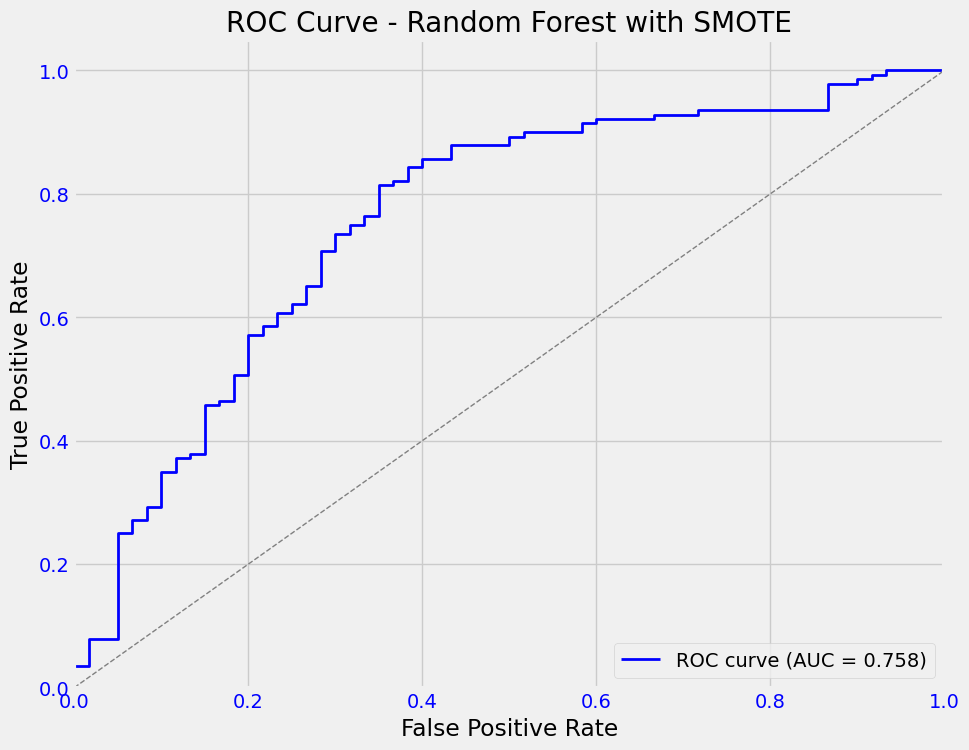

In [85]:
rf_smote_pipeline.fit(X_train, y_train)
y_proba = rf_smote_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest with SMOTE')
plt.legend(loc='lower right')
plt.show()

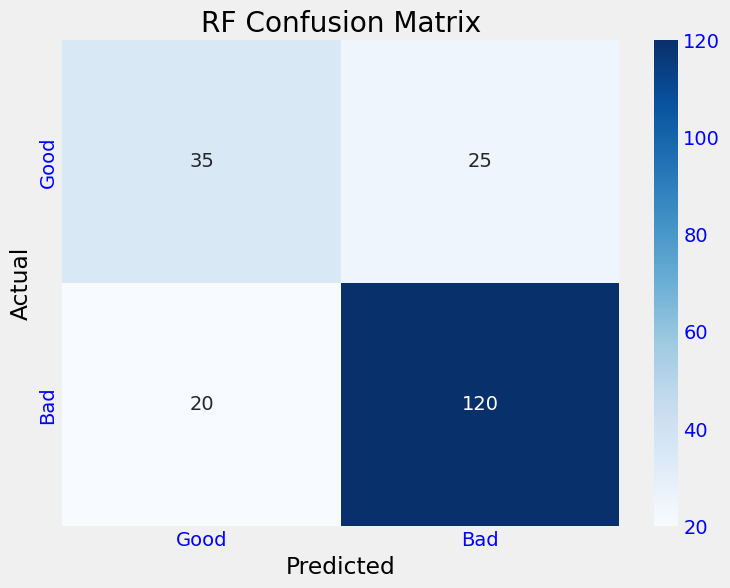

In [86]:
y_pred = rf_smote_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Good', 'Bad'],
            yticklabels=['Good', 'Bad'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('RF Confusion Matrix')
plt.show()

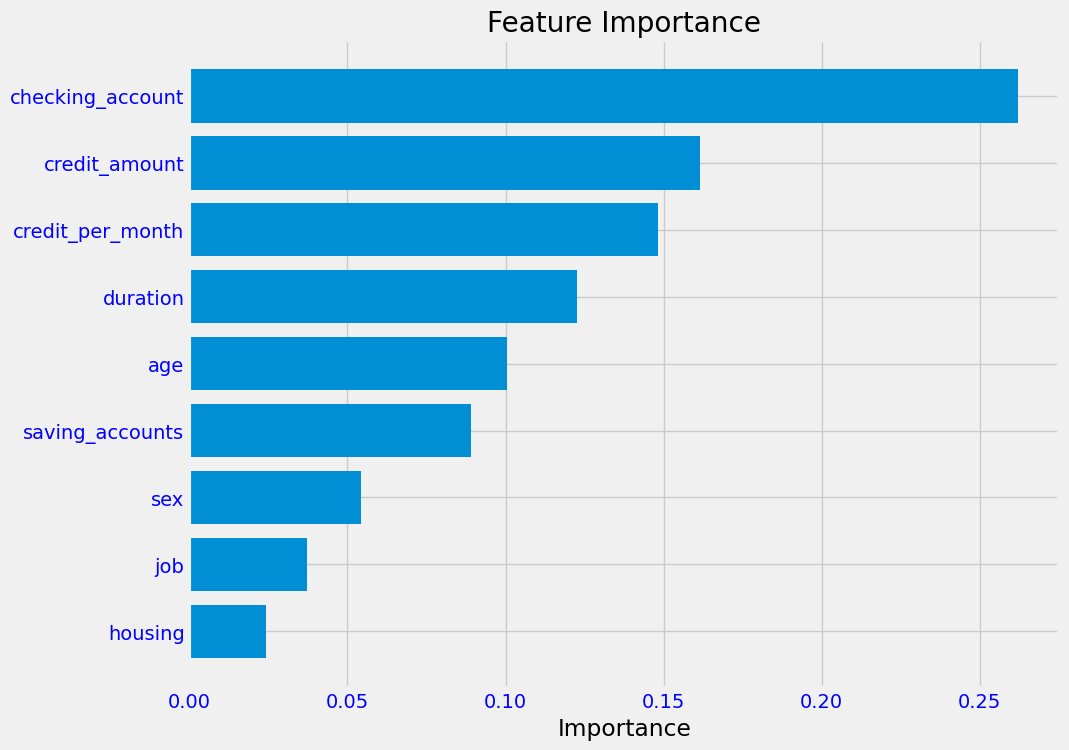

In [87]:
feature_importance = rf_smote_pipeline.named_steps['classifier'].feature_importances_
feature_names = X_train.columns
# Sort and plot
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

#### 5.4.2. XGBClassifier Evaluation

In [88]:
pprint(f"XGB with SMOTE F1 {xgb_f1_smote}")
pprint(f"Best params XGB SMOTE {grid.best_params_}")

'XGB with SMOTE F1 0.8214285714285714'
("Best params XGB SMOTE {'classifier__colsample_bytree': 0.7, "
 "'classifier__learning_rate': 0.1, 'classifier__max_depth': None, "
 "'classifier__n_estimators': 100, 'classifier__subsample': 0.7}")


In [89]:
xgb_smote_pipeline = ImbPipeline([    
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        n_estimators=100,
        max_depth=None,
        learning_rate=0.1,
        colsample_bytree=0.7,
        subsample=0.7,
        random_state=42,
        class_weight = "balanced",
        n_jobs=-1
    ))
])

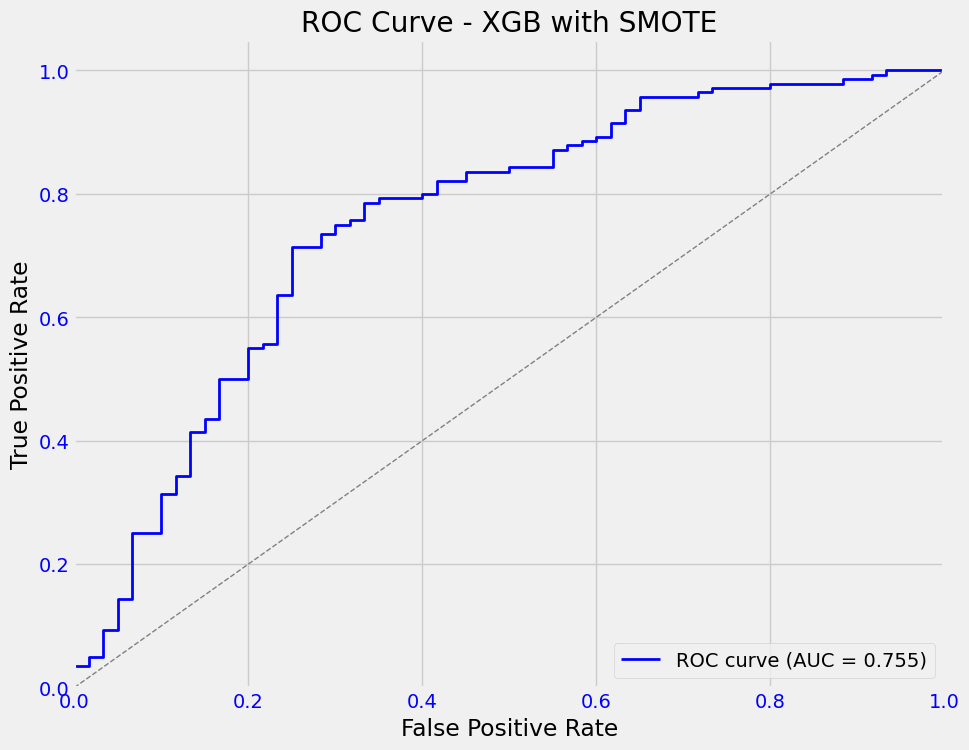

In [90]:
xgb_smote_pipeline.fit(X_train, y_train)
y_proba = xgb_smote_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGB with SMOTE')
plt.legend(loc='lower right')
plt.show()

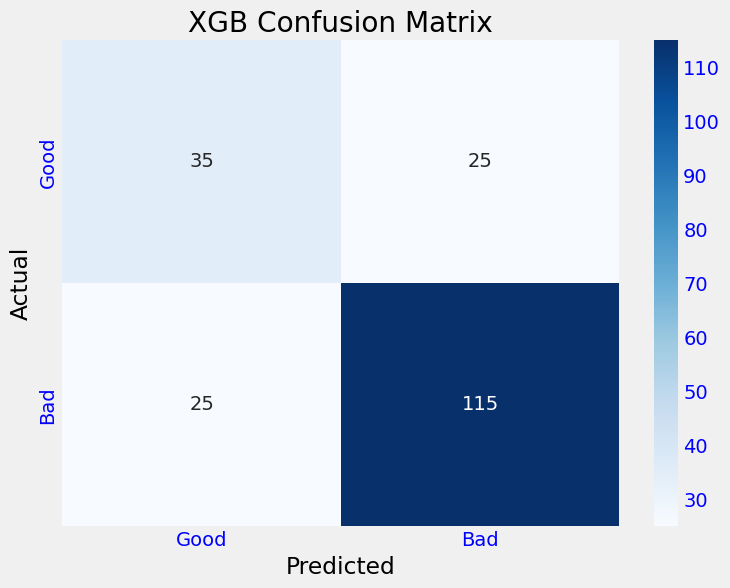

In [91]:
y_pred = xgb_smote_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Good', 'Bad'],
            yticklabels=['Good', 'Bad'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGB Confusion Matrix')
plt.show()

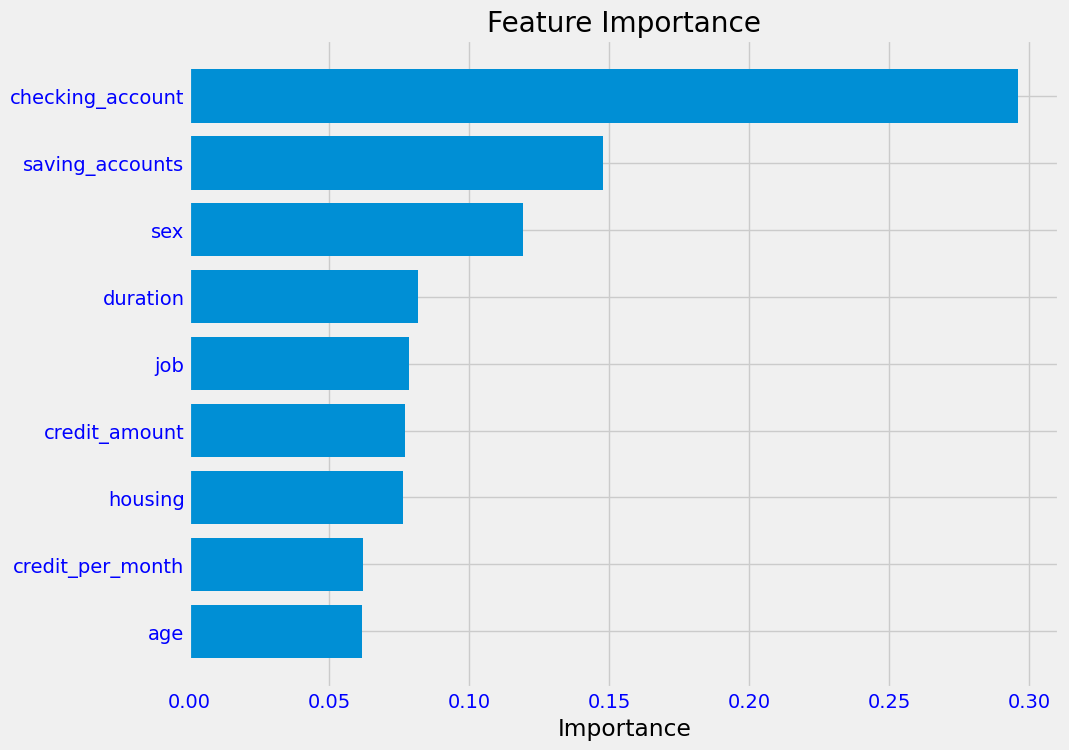

In [92]:
feature_importance = xgb_smote_pipeline.named_steps['classifier'].feature_importances_
feature_names = X_train.columns
# Sort and plot
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

## 6. Final Pipeline

In [93]:
rf_smote_pipeline

,steps,"[('smote', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10


In [94]:
y_pred = rf_smote_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.58      0.61        60
           1       0.83      0.86      0.84       140

    accuracy                           0.78       200
   macro avg       0.73      0.72      0.73       200
weighted avg       0.77      0.78      0.77       200



In [95]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 35  25]
 [ 20 120]]


In [96]:
cat_cols

Index(['sex', 'housing', 'saving_accounts', 'checking_account'], dtype='object')

In [97]:
# feature names
joblib.dump(features, 'feature_names.pkl')

# target encoder
joblib.dump(target_label_encoder, "target_encoder.pkl")

# target mapping
joblib.dump(target_mapping, 'target_mapping.pkl')

# pipeline
joblib.dump(rf_smote_pipeline, 'rf_smote_pipeline.pkl')

# train test split
joblib.dump(X_test, 'X_test.pkl')
joblib.dump(y_test, 'y_test.pkl')

# column label encoders
for col in cat_cols:
    joblib.dump(feat_label_encoder, f"{col}_encoder.pkl")

# metrics
metrics = {"f1": 0.84, "auc": 0.758}
joblib.dump(metrics, 'metrics.pkl')

['metrics.pkl']